In [10]:
# Cell 1: Import Libraries and Setup
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import mean_squared_error
from tensorflow.keras.metrics import MeanSquaredError
from tensorflow.keras.losses import MeanSquaredError as MSE_Loss

import warnings
import os
warnings.filterwarnings('ignore')

# Ensure plots are displayed inline
%matplotlib inline
plt.style.use('default')

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:
# Cell 2: Data Loading and Inspection
def load_datasets():
    """Load datasets from local directory"""
    try:
        # Update these paths to match your local file structure
#        df1 = pd.read_csv("./dataset_done_chunk1_57H.csv")
#        df2 = pd.read_csv("./dataset_done_chunk1_57H_cleaned.csv")
        df3 = pd.read_csv("C:/Users/farah/Desktop/dataset done/dataset_done_chunk1_57H_cleaned_preprocessed.csv")

        
 #       print(f"Dataset 1 shape: {df1.shape}")
 #       print(f"Dataset 2 shape: {df2.shape}")
        print(f"Dataset 3 shape: {df3.shape}")
        
        return df3 # , df2, df3
    except FileNotFoundError as e:
        print(f"Error: File not found - {e}")
        print("Please ensure the CSV files are in the same directory as this notebook.")
        print("Expected files:")
        print("- dataset_done_chunk1_57H.csv")
        print("- dataset_done_chunk1_57H_cleaned.csv")
        print("- dataset_done_chunk1_57H_cleaned_preprocessed.csv")
        return None, None, None

def inspect_data_size(df1):
    """Inspect data sizes and provide recommendations"""
    if df1 is not None:
        total_size = len(df1) 
        print(f"Total combined data size: {total_size:,} rows")
        
        if total_size > 50000:
            print("WARNING: Large dataset detected!")
            print("For ARIMA model training, we recommend:")
            print(f"- Current size: {total_size:,} rows")
            print("- Recommended for ARIMA: 10,000-50,000 rows")
            print("- The code will automatically sample data to prevent memory issues")
            print("- Consider using only the most recent data for time series modeling")
        
        return total_size
    return 0

# Test data loading and inspection
df1 = load_datasets()
if df1 is not None:
    total_size = inspect_data_size(df1)
    
    # Display column information
    print("\nColumn information:")
    print("Dataset 1 columns:", df1.columns.tolist())

Dataset 3 shape: (227778, 14)
Total combined data size: 227,778 rows
For ARIMA model training, we recommend:
- Current size: 227,778 rows
- Recommended for ARIMA: 10,000-50,000 rows
- The code will automatically sample data to prevent memory issues
- Consider using only the most recent data for time series modeling

Column information:
Dataset 1 columns: ['timestamp', 'tx_hash', 'pendingTX', 'gasPrice', 'maxPriorityFeePerGas', 'maxFeePerGas', 'block_number', 'tx_effectiveGasPrice', 'block_timestamp', 'baseFee', 'priorityFee', 'confirmation_time', 'confirmation_time_imputed', 'was_imputed']


Merging datasets...
Combined dataset shape: (227778, 14)
Shape after removing duplicates: (227778, 14)
Handling missing values...
  baseFee: 1 missing values filled with median
  priorityFee: 1 missing values filled with median
  confirmation_time: 1 missing values filled with median
Final cleaned dataset shape: (227778, 13)
Data cleaning completed successfully!

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 227778 entries, 1970-01-01 00:00:01.744721972 to 1970-01-01 00:00:01.744752271
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   tx_hash                    227778 non-null  object        
 1   pendingTX                  227778 non-null  float64       
 2   gasPrice                   227778 non-null  float64       
 3   maxPriorityFeePerGas       227778 non-null  float64       
 4   maxFeePerGas               227778 non-null  float64       
 5   bl

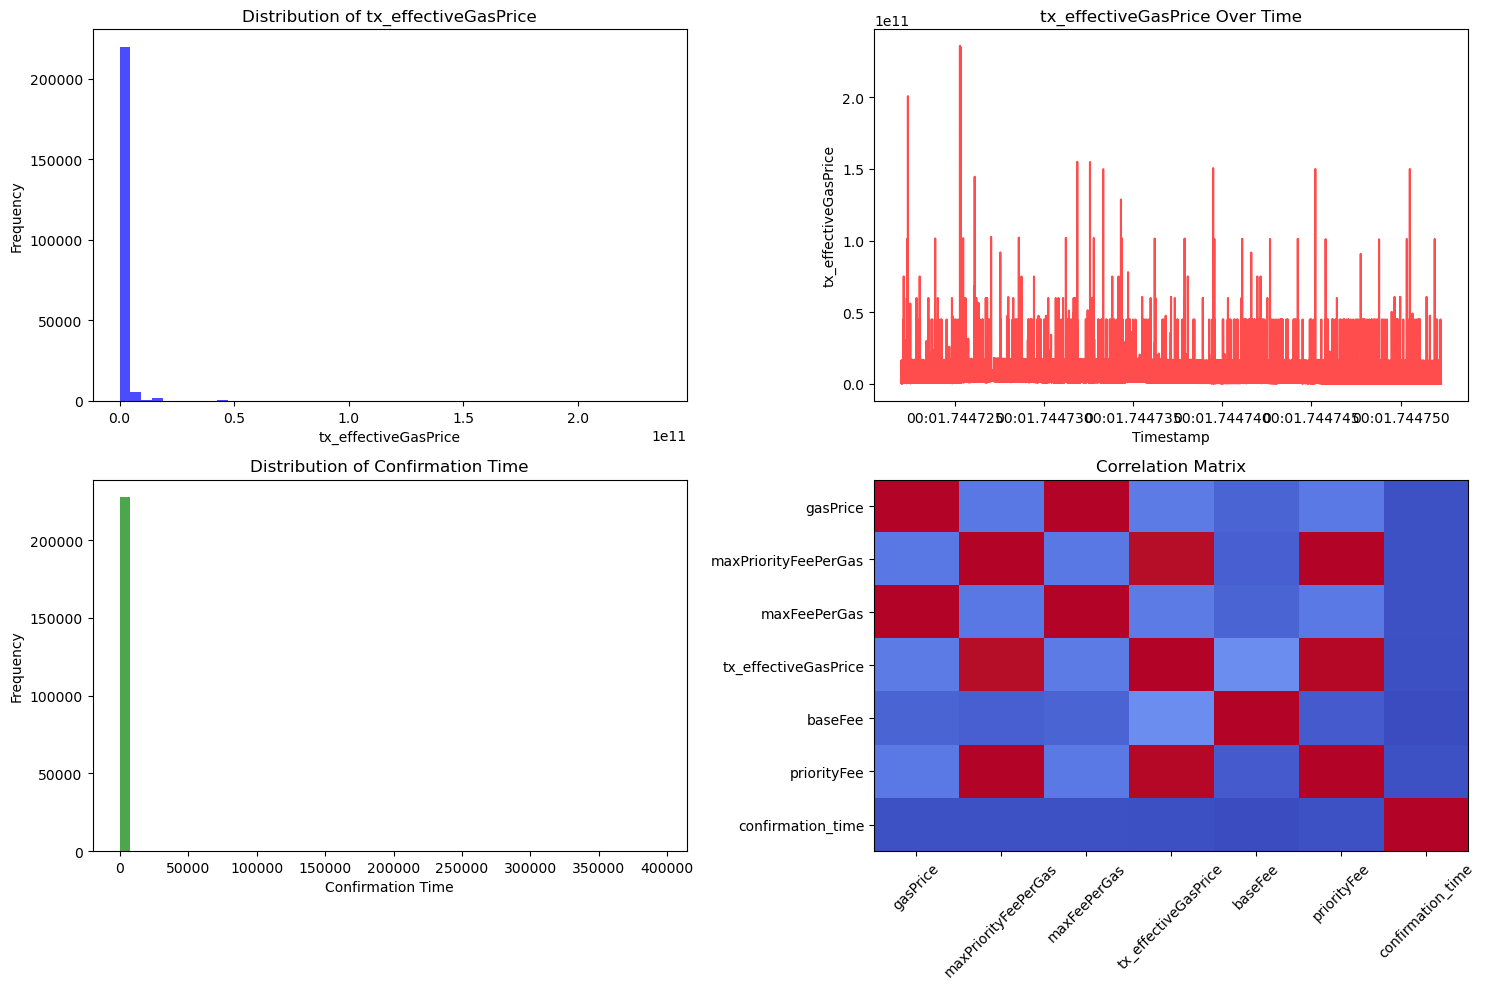

In [14]:
import matplotlib.pyplot as plt
# Cell 3: Data Preprocessing Functions
def merge_and_clean_data(df1):
    """Merge and clean the datasets"""
    print("Merging datasets...")
    df = df1
    print(f"Combined dataset shape: {df.shape}")
    
    # Remove duplicates
    df.drop_duplicates(inplace=True)
    print(f"Shape after removing duplicates: {df.shape}")

    # Convert timestamp columns
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["block_timestamp"] = pd.to_datetime(df["block_timestamp"])

    # Handle missing values
    numeric_cols = ["gasPrice", "maxPriorityFeePerGas", "maxFeePerGas", 
                   "tx_effectiveGasPrice", "baseFee", "priorityFee", "confirmation_time"]
    
    print("Handling missing values...")
    for col in numeric_cols:
        if col in df.columns:
            missing_count = df[col].isnull().sum()
            if missing_count > 0:
                print(f"  {col}: {missing_count} missing values filled with median")
                df[col].fillna(df[col].median(), inplace=True)

#     # Remove rows with missing critical values
#     df.dropna(subset=["confirmation_time", "tx_effectiveGasPrice"], inplace=True)
#     print(f"Shape after removing critical missing values: {df.shape}")

#     # Handle outliers using IQR method
#     print("Handling outliers...")
#     for col in numeric_cols:
#         if col in df.columns:
#             Q1 = df[col].quantile(0.25)
#             Q3 = df[col].quantile(0.75)
#             IQR = Q3 - Q1
#             lower_bound = Q1 - 1.5 * IQR
#             upper_bound = Q3 + 1.5 * IQR
            
#             outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
#             if outliers_count > 0:
#                 print(f"  {col}: {outliers_count} outliers capped")
#                 df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
#                 df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    # Sort by timestamp and set as index
    df = df.sort_values(by="timestamp").set_index("timestamp")
    print(f"Final cleaned dataset shape: {df.shape}")
    
    return df

# Apply data cleaning if datasets were loaded successfully
if df1 is not None:
    df_cleaned = merge_and_clean_data(df1)
    print("Data cleaning completed successfully!")
    
    # Display basic statistics
    print("\nDataset Info:")
    print(df_cleaned.info())
    
    # Plot data distribution
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Target variable distribution
    axes[0,0].hist(df_cleaned['tx_effectiveGasPrice'], bins=50, alpha=0.7, color='blue')
    axes[0,0].set_title('Distribution of tx_effectiveGasPrice')
    axes[0,0].set_xlabel('tx_effectiveGasPrice')
    axes[0,0].set_ylabel('Frequency')
    
    # Time series plot
    axes[0,1].plot(df_cleaned.index, df_cleaned['tx_effectiveGasPrice'], alpha=0.7, color='red')
    axes[0,1].set_title('tx_effectiveGasPrice Over Time')
    axes[0,1].set_xlabel('Timestamp')
    axes[0,1].set_ylabel('tx_effectiveGasPrice')
    
    # Confirmation time distribution
    axes[1,0].hist(df_cleaned['confirmation_time'], bins=50, alpha=0.7, color='green')
    axes[1,0].set_title('Distribution of Confirmation Time')
    axes[1,0].set_xlabel('Confirmation Time')
    axes[1,0].set_ylabel('Frequency')
    
    # Correlation heatmap
    numeric_cols = ["gasPrice", "maxPriorityFeePerGas", "maxFeePerGas", 
                   "tx_effectiveGasPrice", "baseFee", "priorityFee", "confirmation_time"]
    corr_matrix = df_cleaned[numeric_cols].corr()
    im = axes[1,1].imshow(corr_matrix, cmap='coolwarm', aspect='auto')
    axes[1,1].set_title('Correlation Matrix')
    axes[1,1].set_xticks(range(len(numeric_cols)))
    axes[1,1].set_yticks(range(len(numeric_cols)))
    axes[1,1].set_xticklabels(numeric_cols, rotation=45)
    axes[1,1].set_yticklabels(numeric_cols)
    
    plt.tight_layout()
    plt.show()
else:
    print("Cannot proceed without datasets. Please check your file paths.")

Scaling features...
Features scaled: ['gasPrice', 'maxPriorityFeePerGas', 'maxFeePerGas', 'baseFee', 'priorityFee', 'confirmation_time']
Target scaled: tx_effectiveGasPrice
Scalers saved successfully!
MLP sequences created:
X_mlp shape: (227773, 5, 7)
y_mlp shape: (227773,)


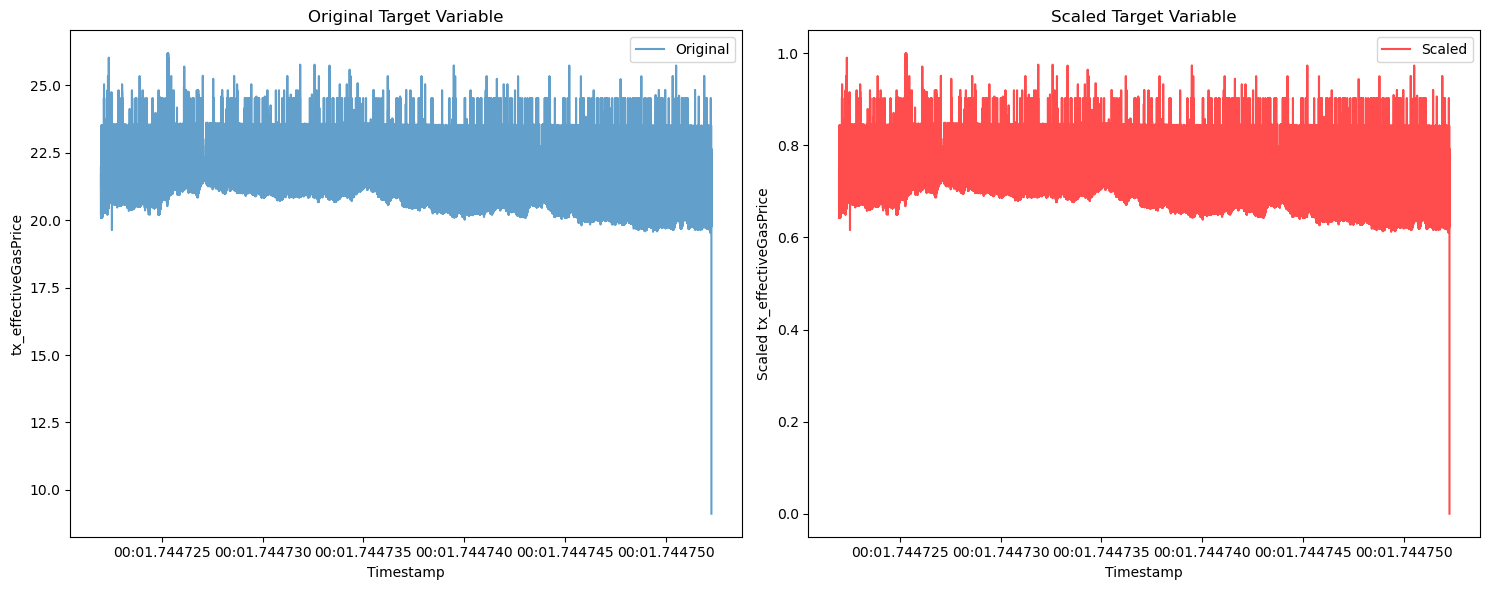

In [16]:
# Cell 4: Feature Scaling Functions
def scale_features(df, features_to_scale, target_col):
    """Scale features and target variable"""
    print("Scaling features...")
    
    # Create scalers
    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()
    
    # Scale features
    df[features_to_scale] = feature_scaler.fit_transform(df[features_to_scale])
    
    # Scale target
    df[target_col] = target_scaler.fit_transform(df[[target_col]])
    
    print(f"Features scaled: {features_to_scale}")
    print(f"Target scaled: {target_col}")
    
    return df, feature_scaler, target_scaler

def create_sequences(data, n_steps):
    """Create sequences for MLP"""
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:(i + n_steps), :])
        y.append(data[i + n_steps, -1])
    return np.array(X), np.array(y)

# Apply scaling if data cleaning was successful
if 'df_cleaned' in locals():
    features = ["gasPrice", "maxPriorityFeePerGas", "maxFeePerGas", 
               "baseFee", "priorityFee", "confirmation_time"]
    target = "tx_effectiveGasPrice"
    
    # Check if all required columns exist
    missing_cols = [col for col in features + [target] if col not in df_cleaned.columns]
    if missing_cols:
        print(f"Error: Missing columns: {missing_cols}")
    else:
        # Store original target for ARIMA and apply log scaling
       # original_target_series = df_cleaned[target].copy()
        # Store original target for ARIMA and apply log scaling
        original_target_series = np.log1p(df_cleaned[target].copy())

        df_log_scaled = df_cleaned.copy()
        df_log_scaled[target] = np.log1p(df_log_scaled[target])

        # Scale the data
        df_scaled, feature_scaler, target_scaler = scale_features(df_log_scaled, features, target)

        
        # Save scalers
        with open("feature_scaler.pkl", "wb") as f:
            pickle.dump(feature_scaler, f)
        with open("target_scaler.pkl", "wb") as f:
            pickle.dump(target_scaler, f)
        
        print("Scalers saved successfully!")
        
        # Create sequences for MLP
        n_steps = 5
        X_mlp, y_mlp = create_sequences(df_scaled[features + [target]].values, n_steps)
        
        print(f"MLP sequences created:")
        print(f"X_mlp shape: {X_mlp.shape}")
        print(f"y_mlp shape: {y_mlp.shape}")
        
        # Plot scaled vs original data
        plt.figure(figsize=(15, 6))
        
        plt.subplot(1, 2, 1)
        plt.plot(original_target_series.index, original_target_series, alpha=0.7, label='Original')
        plt.title('Original Target Variable')
        plt.xlabel('Timestamp')
        plt.ylabel('tx_effectiveGasPrice')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(df_scaled.index, df_scaled[target], alpha=0.7, label='Scaled', color='red')
        plt.title('Scaled Target Variable')
        plt.xlabel('Timestamp')
        plt.ylabel('Scaled tx_effectiveGasPrice')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

Starting ARIMA training...
Original target series size: 227778
Training ARIMA model...
Original data size: 227778
Data too large for ARIMA. Sampling 10000 points...
Sampled data size: 10000
Train data size: 8000
Test data size: 2000
Fitting ARIMA model...
ARIMA model fitted successfully!
AIC: 14820.65
BIC: 14862.58
Generating training predictions...
Generating test predictions...
Processed 100/2000 test predictions
Processed 300/2000 test predictions
Processed 500/2000 test predictions
Processed 700/2000 test predictions
Processed 900/2000 test predictions
Processed 1100/2000 test predictions
Processed 1300/2000 test predictions
Processed 1500/2000 test predictions
Processed 1700/2000 test predictions
Processed 1900/2000 test predictions
ARIMA Train MSE: 0.4316
ARIMA Test MSE: 1.2442


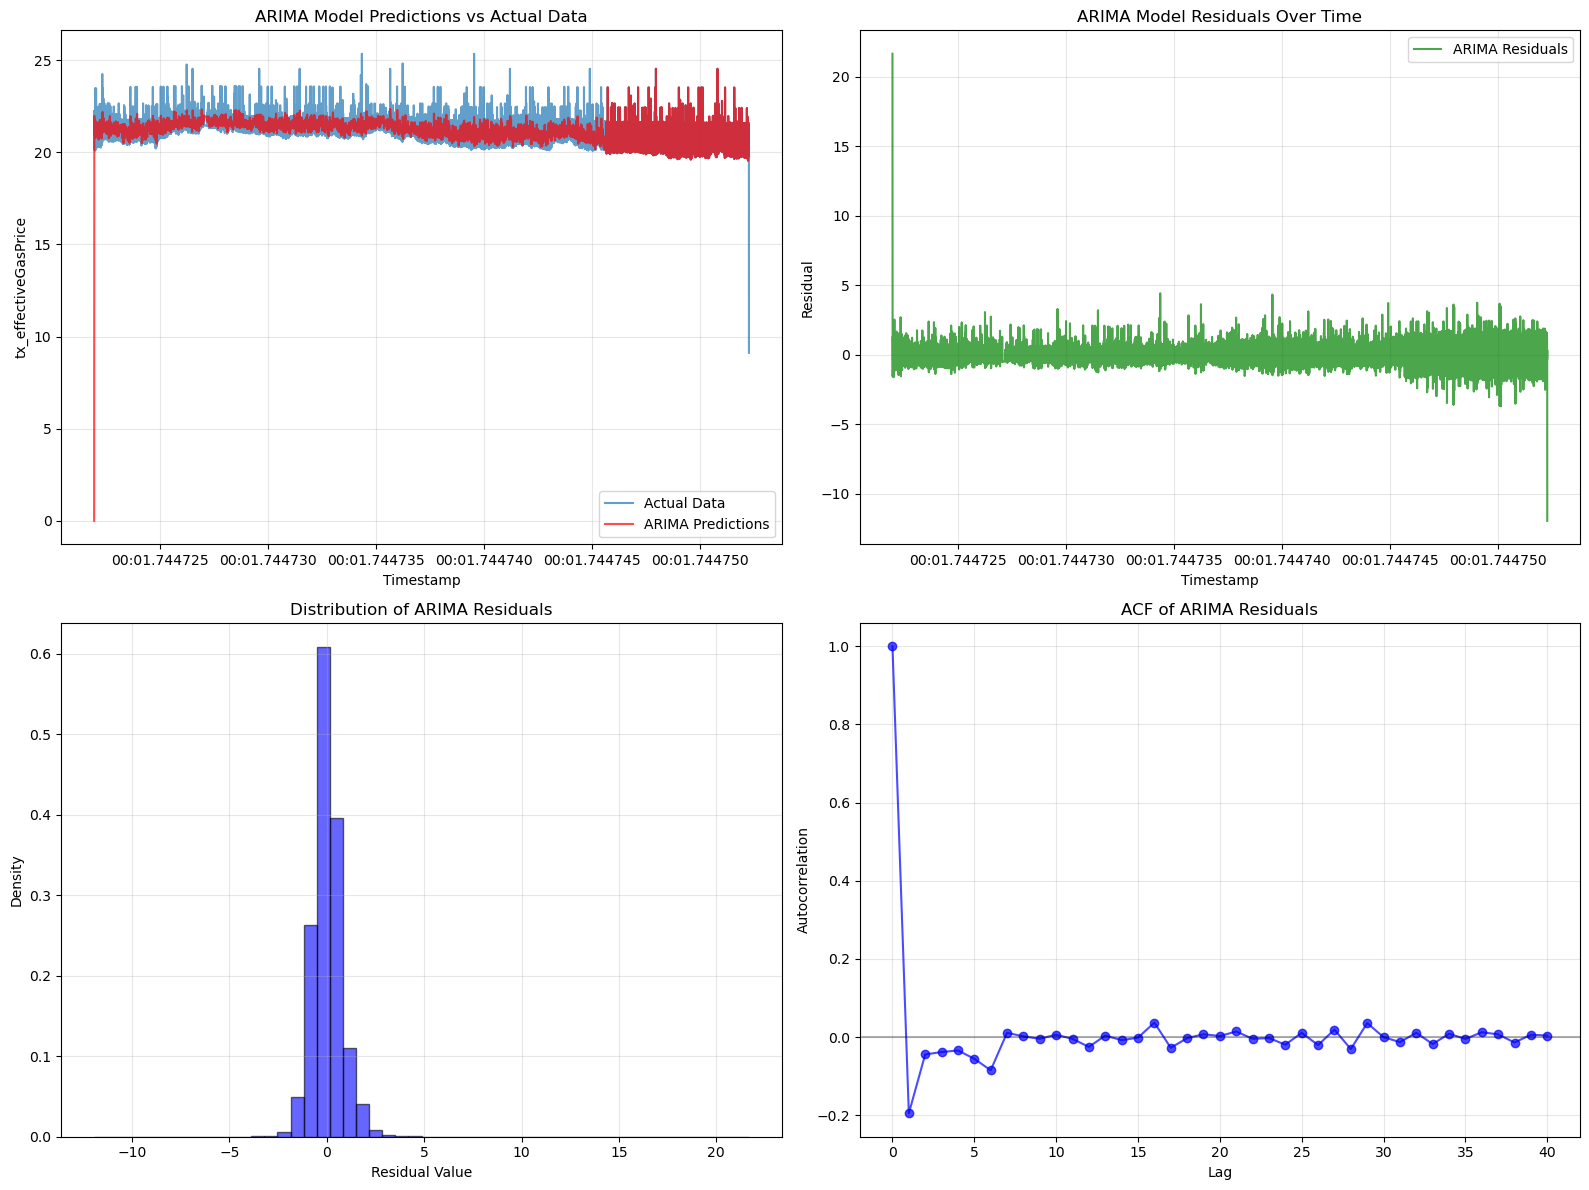

ARIMA model and residuals saved successfully!
ARIMA residuals shape: (10000,)
Residuals statistics:
count    10000.000000
mean         0.000372
std          0.770824
min        -11.949341
25%         -0.460084
50%         -0.036213
75%          0.425927
max         21.673415
dtype: float64


In [18]:
from sklearn.metrics import mean_squared_error

# Cell 5: ARIMA Model Training
def train_arima_and_get_residuals(data_series, order=(5,1,0), sample_size=10000):
    """Train ARIMA model and calculate residuals with memory optimization"""
    print("Training ARIMA model...")
    print(f"Original data size: {len(data_series)}")
    
    # reduce ranges with log transform
  ##  data_series = np.log1p(data_series)
    
    # Sample data if too large to prevent memory issues
    if len(data_series) > sample_size:
        print(f"Data too large for ARIMA. Sampling {sample_size} points...")
        # Take evenly spaced samples to maintain temporal structure
        indices = np.linspace(0, len(data_series)-1, sample_size, dtype=int)
        data_series = data_series.iloc[indices]
        print(f"Sampled data size: {len(data_series)}")
    
    # Split data
    train_size = int(len(data_series) * 0.8)
    train_data, test_data = data_series[0:train_size], data_series[train_size:]
    
    print(f"Train data size: {len(train_data)}")
    print(f"Test data size: {len(test_data)}")
    
    # Train ARIMA model with memory optimization
    print("Fitting ARIMA model...")
    try:
        model = ARIMA(train_data, order=order)
        model_fit = model.fit()  # Use L-BFGS for better memory usage
        
        print("ARIMA model fitted successfully!")
        print(f"AIC: {model_fit.aic:.2f}")
        print(f"BIC: {model_fit.bic:.2f}")
        
    except Exception as e:
        print(f"Error fitting ARIMA with order {order}: {e}")
        print("Trying simpler ARIMA model...")
        try:
            model = ARIMA(train_data, order=(1,1,1))  # Simpler model
            model_fit = model.fit()
            order = (1,1,1)
            print(f"Fitted ARIMA{order} successfully!")
            print(f"AIC: {model_fit.aic:.2f}")
            print(f"BIC: {model_fit.bic:.2f}")
        except Exception as e2:
            print(f"Error with simple ARIMA: {e2}")
            print("Using even simpler model...")
            model = ARIMA(train_data, order=(1,0,1))
            model_fit = model.fit()
            order = (1,0,1)
            print(f"Fitted ARIMA{order} successfully!")
            print(f"AIC: {model_fit.aic:.2f}")
            print(f"BIC: {model_fit.bic:.2f}")
    
    # Get training predictions and residuals
    print("Generating training predictions...")
    train_predictions = model_fit.predict(start=0, end=len(train_data)-1)
    train_residuals = train_data - train_predictions
    
    # Get test predictions and residuals with batch processing
    print("Generating test predictions...")
    test_predictions = []
    history = list(train_data.values)  # Convert to list for faster appending
    
    # Process in smaller batches to save memory
    batch_size = min(100, len(test_data))
    for i in range(0, len(test_data), batch_size):
        batch_end = min(i + batch_size, len(test_data))
        batch_test = test_data.iloc[i:batch_end]
        
        for j, obs in enumerate(batch_test):
            try:
                # Use the existing model_fit for forecasting when possible
                if len(history) == len(train_data):
                    # First prediction - use original model
                    forecast = model_fit.forecast(steps=1)
                    yhat = forecast.iloc[0] if isinstance(forecast, pd.Series) else forecast[0]
                else:
                    # Subsequent predictions - refit only occasionally to save memory
                    if (len(history) - len(train_data)) % 50 == 0:  # Refit every 50 steps
                        model_temp = ARIMA(history, order=order)
                        model_fit_temp = model_temp.fit()
                        forecast = model_fit_temp.forecast(steps=1)
                        yhat = forecast.iloc[0] if isinstance(forecast, pd.Series) else forecast[0]
                    else:
                        # Use simple prediction for intermediate steps
                        yhat = history[-1]  # Naive forecast to save computation
                
                test_predictions.append(yhat)
                history.append(obs)
                
            except Exception as e:
                print(f"Error in prediction step {i+j}: {e}")
                # Fallback to naive forecast
                yhat = history[-1] if history else test_data.iloc[0]
                test_predictions.append(yhat)
                history.append(obs)
        
        if i % 200 == 0:  # Progress update
            print(f"Processed {min(i+batch_size, len(test_data))}/{len(test_data)} test predictions")
    
    test_predictions = pd.Series(test_predictions, index=test_data.index)
    test_residuals = test_data - test_predictions
    
    # Combine residuals
    all_residuals = pd.concat([train_residuals, test_residuals])
    all_predictions = pd.concat([train_predictions, test_predictions])
    
    # Calculate performance metrics
    train_mse = mean_squared_error(train_data, train_predictions)
    test_mse = mean_squared_error(test_data, test_predictions)
    
    print(f"ARIMA Train MSE: {train_mse:.4f}")
    print(f"ARIMA Test MSE: {test_mse:.4f}")
    
    # Plot ARIMA results
    plt.figure(figsize=(16, 12))
    
    # Plot predictions vs actual
    plt.subplot(2, 2, 1)
    plt.plot(data_series.index, data_series, label="Actual Data", alpha=0.7)
    plt.plot(all_predictions.index, all_predictions, color="red", label="ARIMA Predictions", alpha=0.7)
    plt.title("ARIMA Model Predictions vs Actual Data")
    plt.xlabel("Timestamp")
    plt.ylabel("tx_effectiveGasPrice")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot residuals over time
    plt.subplot(2, 2, 2)
    plt.plot(all_residuals.index, all_residuals, label="ARIMA Residuals", color="green", alpha=0.7)
    plt.title("ARIMA Model Residuals Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Residual")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot residual distribution
    plt.subplot(2, 2, 3)
    plt.hist(all_residuals.dropna(), bins=50, density=True, alpha=0.6, color="blue", edgecolor='black')
    plt.title("Distribution of ARIMA Residuals")
    plt.xlabel("Residual Value")
    plt.ylabel("Density")
    plt.grid(True, alpha=0.3)
    
    # Plot ACF of residuals
    plt.subplot(2, 2, 4)
    try:
        from statsmodels.tsa.stattools import acf
        residuals_clean = all_residuals.dropna()
        lags = min(40, len(residuals_clean)//4)
        acf_values = acf(residuals_clean, nlags=lags, fft=True)
        plt.plot(range(len(acf_values)), acf_values, 'bo-', alpha=0.7)
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.title("ACF of ARIMA Residuals")
        plt.xlabel("Lag")
        plt.ylabel("Autocorrelation")
        plt.grid(True, alpha=0.3)
    except Exception as e:
        print(f"Could not plot ACF: {e}")
        plt.text(0.5, 0.5, f"ACF plot unavailable:\n{str(e)}", 
                transform=plt.gca().transAxes, ha='center', va='center')
        plt.title("ACF of ARIMA Residuals")
    
    plt.tight_layout()
    plt.show()
    
    # Save ARIMA model and residuals
    with open("arima_model.pkl", "wb") as f:
        pickle.dump(model_fit, f)
    with open("arima_residuals.pkl", "wb") as f:
        pickle.dump(all_residuals, f)
    
    print("ARIMA model and residuals saved successfully!")
    
    return all_residuals, test_data.index

# Train ARIMA model if previous steps were successful
if 'original_target_series' in locals():
    print("Starting ARIMA training...")
    print(f"Original target series size: {len(original_target_series)}")
    
    # Add option to reduce sample size if needed
    max_sample_size = 10000  # Adjust this based on your memory
    arima_residuals, test_index = train_arima_and_get_residuals(original_target_series, sample_size=max_sample_size)
    print(f"ARIMA residuals shape: {arima_residuals.shape}")
    print(f"Residuals statistics:")
    print(arima_residuals.describe())

Building MLP for residual prediction...
MLP input shape: (9995, 5)
MLP target shape: (9995, 1)
Training set size: 5997
Validation set size: 1999
Test set size: 1999
MLP Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,801 (175.00 KB)

 Trainable params: 44,801 (175.00 KB)

 Non-trainable params: 0 (0.00 B)

Training MLP model...
Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0116 - mae: 0.0711 - val_loss: 0.0026 - val_mae: 0.0459
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.5052e-04 - mae: 0.0215 - val_loss: 7.1047e-04 - val_mae: 0.0202
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.9663e-04 - mae: 0.0154 - val_loss: 5.9373e-04 - val_mae: 0.0185
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.1139e-04 - mae: 0.0139 - val_loss: 4.3849e-04 - val_mae: 0.0176
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.2536e-04 - mae: 0.0141 - val_loss: 4.3134e-04 - val_mae: 0.0172
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.0582e-04 - mae: 0.0137 - val_loss: 4.3655e-04 - val_mae: 0.0175
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.0925e-04 - mae: 0.0138 - val_loss: 4.5786e-04 - val_mae: 0.0181
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.2185e-04 - mae: 0.0140 - val_loss:

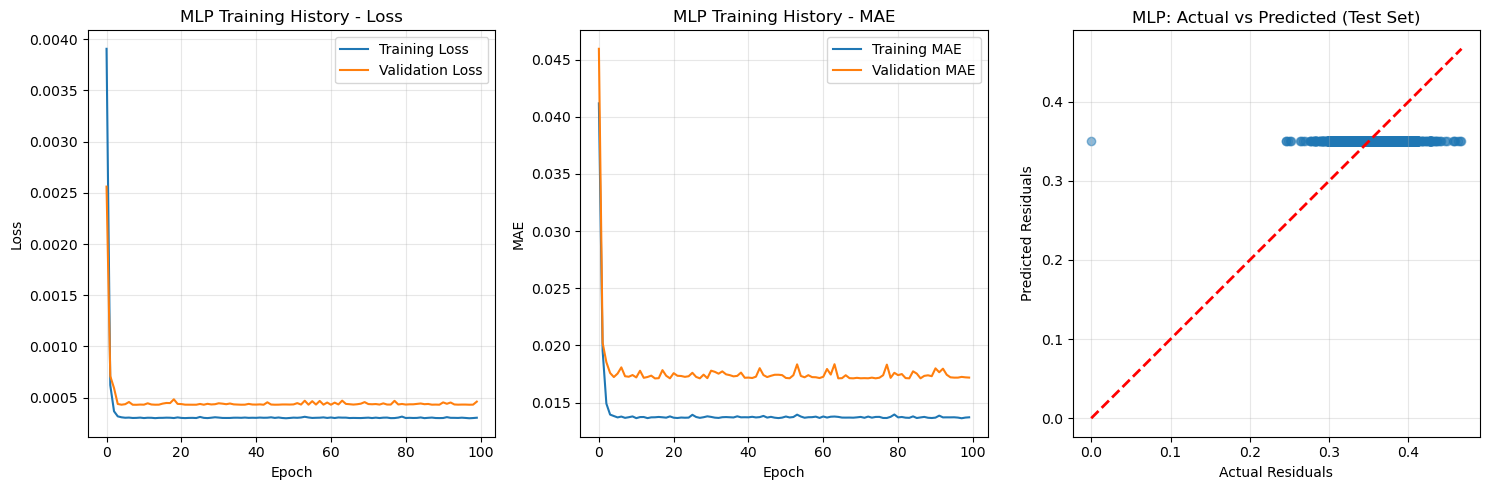

MLP model and scaler saved successfully!


In [13]:
# Cell 6: MLP Model for Residuals
from tensorflow.keras.models import Sequential

def create_sequences_for_residuals(data, n_steps):
    """Create sequences for residual prediction"""
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:(i + n_steps)])
        y.append(data[i + n_steps])
    return np.array(X), np.array(y)

def build_and_train_mlp_for_residuals(residuals_series, n_steps=5):
    """Build and train MLP for residual prediction"""
    print("Building MLP for residual prediction...")
    
    # Convert residuals to numpy array
    residuals = residuals_series.values.reshape(-1, 1)
    
    # Scale residuals
    residual_scaler = MinMaxScaler()
    scaled_residuals = residual_scaler.fit_transform(residuals)
    
    # Create sequences
    X, y = create_sequences_for_residuals(scaled_residuals, n_steps)
    
    # Reshape for MLP
    X = X.reshape(X.shape[0], X.shape[1] * X.shape[2])
    
    print(f"MLP input shape: {X.shape}")
    print(f"MLP target shape: {y.shape}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, shuffle=False)
    
    print(f"Training set size: {X_train.shape[0]}")
    print(f"Validation set size: {X_val.shape[0]}")
    print(f"Test set size: {X_test.shape[0]}")
    
    # Build MLP model
    model = Sequential([
        Dense(256, activation="relu", input_dim=X_train.shape[1]),
        Dropout(0.2),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    
    # Compile model
    model.compile(optimizer="adam", loss="mse", metrics=['mae'])
    
    print("MLP Model Architecture:")
    model.summary()
    
    # Train model
    print("Training MLP model...")
    history = model.fit(
        X_train, y_train, 
        epochs=100, 
        batch_size=32, 
        validation_data=(X_val, y_val), 
        verbose=1
    )
    
    # Evaluate model
    train_loss = model.evaluate(X_train, y_train, verbose=0)
    val_loss = model.evaluate(X_val, y_val, verbose=0)
    test_loss = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"MLP Train Loss: {train_loss[0]:.4f}, Train MAE: {train_loss[1]:.4f}")
    print(f"MLP Validation Loss: {val_loss[0]:.4f}, Validation MAE: {val_loss[1]:.4f}")
    print(f"MLP Test Loss: {test_loss[0]:.4f}, Test MAE: {test_loss[1]:.4f}")
    
    # Plot training history
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("MLP Training History - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.plot(history.history["mae"], label="Training MAE")
    plt.plot(history.history["val_mae"], label="Validation MAE")
    plt.title("MLP Training History - MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot predictions vs actual for test set
    plt.subplot(1, 3, 3)
    y_pred = model.predict(X_test, verbose=0)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title("MLP: Actual vs Predicted (Test Set)")
    plt.xlabel("Actual Residuals")
    plt.ylabel("Predicted Residuals")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Save model and scaler
    model.save("mlp_residuals_model.h5")
    with open("residual_scaler.pkl", "wb") as f:
        pickle.dump(residual_scaler, f)
    
    print("MLP model and scaler saved successfully!")
    
    return model, residual_scaler, X_test, y_test, n_steps

# Train MLP for residuals if ARIMA was successful
if 'arima_residuals' in locals():
    mlp_model, residual_scaler, X_test_mlp, y_test_mlp, n_steps_mlp = build_and_train_mlp_for_residuals(arima_residuals)

Making hybrid prediction for confirmation time: 15 seconds
Model loaded and recompiled successfully
Error during ARIMA forecasting: Given `endog` does not have an index that extends the index of the model.
ARIMA Prediction: 9.1166
MLP Residual Prediction: -0.1841
Base Hybrid Prediction: 8.9325
Congestion Multiplier: 2.00
Urgency Premium: 0.4639
Market Premium: 0.8000
Volatility Factor: 1.0188
Time Residual: 0.1425
Time-Adjusted Prediction: 19.6301
Estimated transaction fee (original scale): 335145922.3932 Gwei


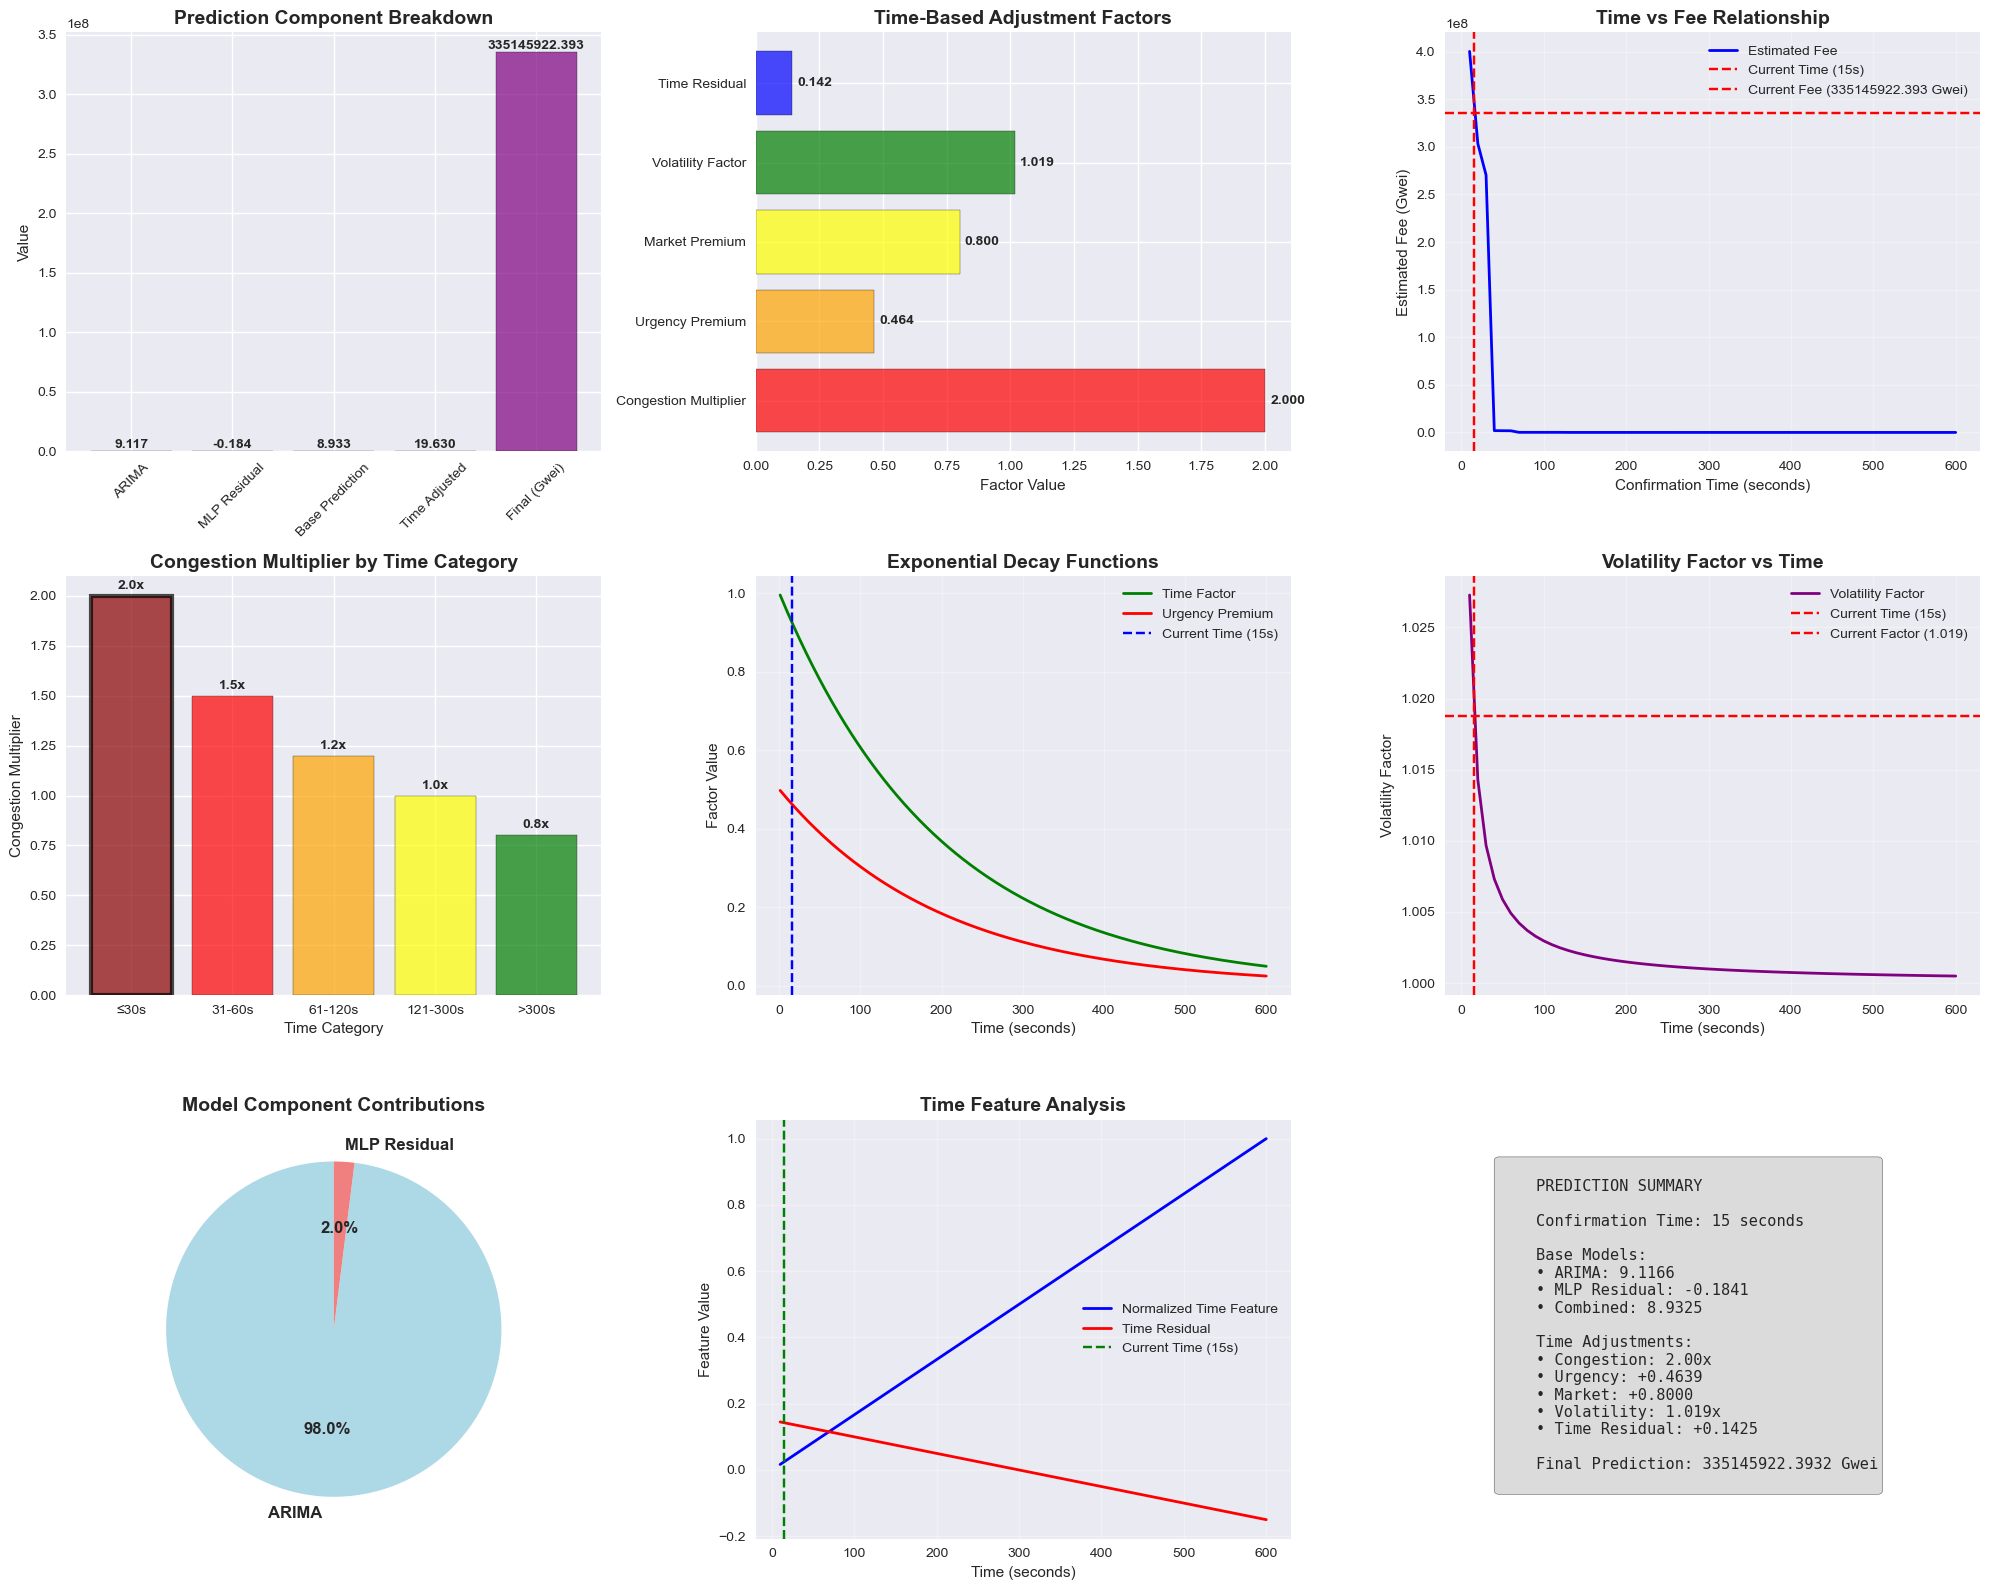


For a desired confirmation time of 15 seconds:
Estimated transaction fee: 335145922.3932 Gwei

TESTING TRUE TIME-BASED PREDICTIONS:

Making hybrid prediction for confirmation time: 30 seconds
Model loaded and recompiled successfully
Error during ARIMA forecasting: Given `endog` does not have an index that extends the index of the model.
ARIMA Prediction: 9.1166
MLP Residual Prediction: -0.1841
Base Hybrid Prediction: 8.9325
Congestion Multiplier: 2.00
Urgency Premium: 0.4304
Market Premium: 0.8000
Volatility Factor: 1.0097
Time Residual: 0.1350
Time-Adjusted Prediction: 19.4152
Estimated transaction fee (original scale): 270338622.5476 Gwei
Time: 30s → Fee: 270338622.5476 Gwei

Making hybrid prediction for confirmation time: 60 seconds
Model loaded and recompiled successfully
Error during ARIMA forecasting: Given `endog` does not have an index that extends the index of the model.
ARIMA Prediction: 9.1166
MLP Residual Prediction: -0.1841
Base Hybrid Prediction: 8.9325
Congestion Multip

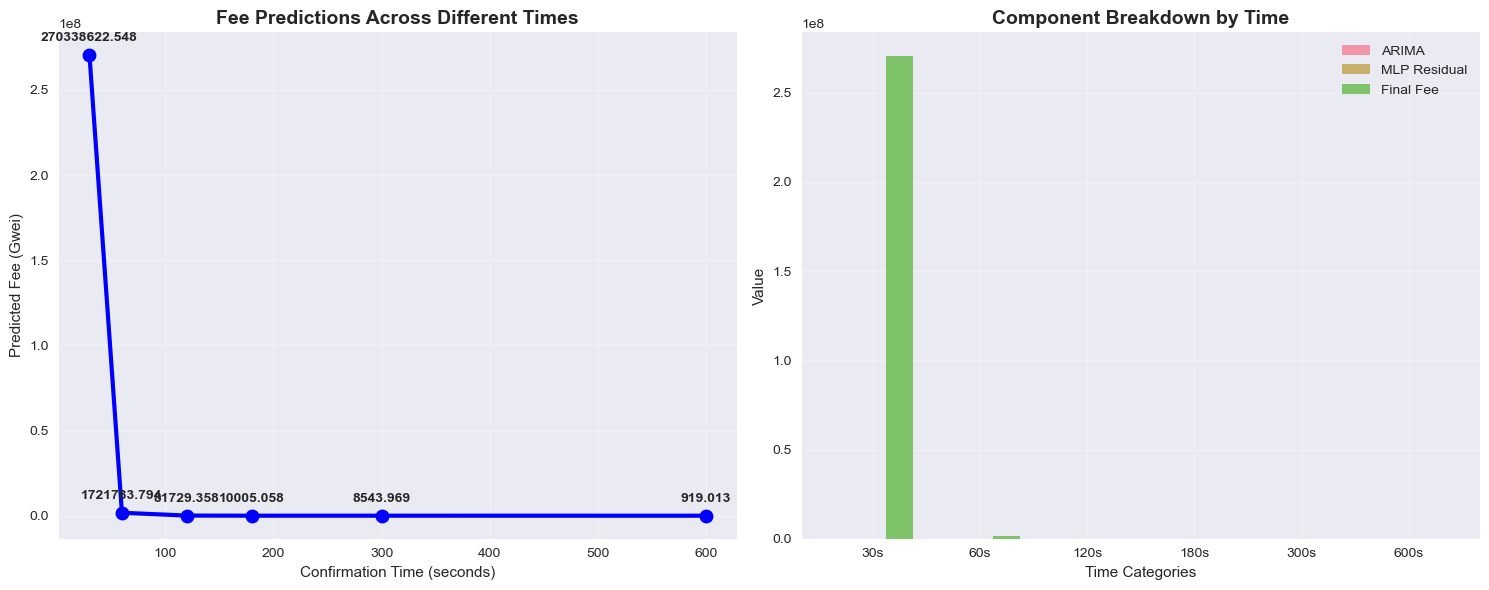


Running comprehensive time sensitivity analysis...
Running time sensitivity analysis...
Making hybrid prediction for confirmation time: 15 seconds
Model loaded and recompiled successfully
Error during ARIMA forecasting: Given `endog` does not have an index that extends the index of the model.
ARIMA Prediction: 9.1166
MLP Residual Prediction: -0.1841
Base Hybrid Prediction: 8.9325
Congestion Multiplier: 2.00
Urgency Premium: 0.4639
Market Premium: 0.8000
Volatility Factor: 1.0188
Time Residual: 0.1425
Time-Adjusted Prediction: 19.6301
Estimated transaction fee (original scale): 335145922.3932 Gwei
Making hybrid prediction for confirmation time: 30 seconds
Model loaded and recompiled successfully
Error during ARIMA forecasting: Given `endog` does not have an index that extends the index of the model.
ARIMA Prediction: 9.1166
MLP Residual Prediction: -0.1841
Base Hybrid Prediction: 8.9325
Congestion Multiplier: 2.00
Urgency Premium: 0.4304
Market Premium: 0.8000
Volatility Factor: 1.0097

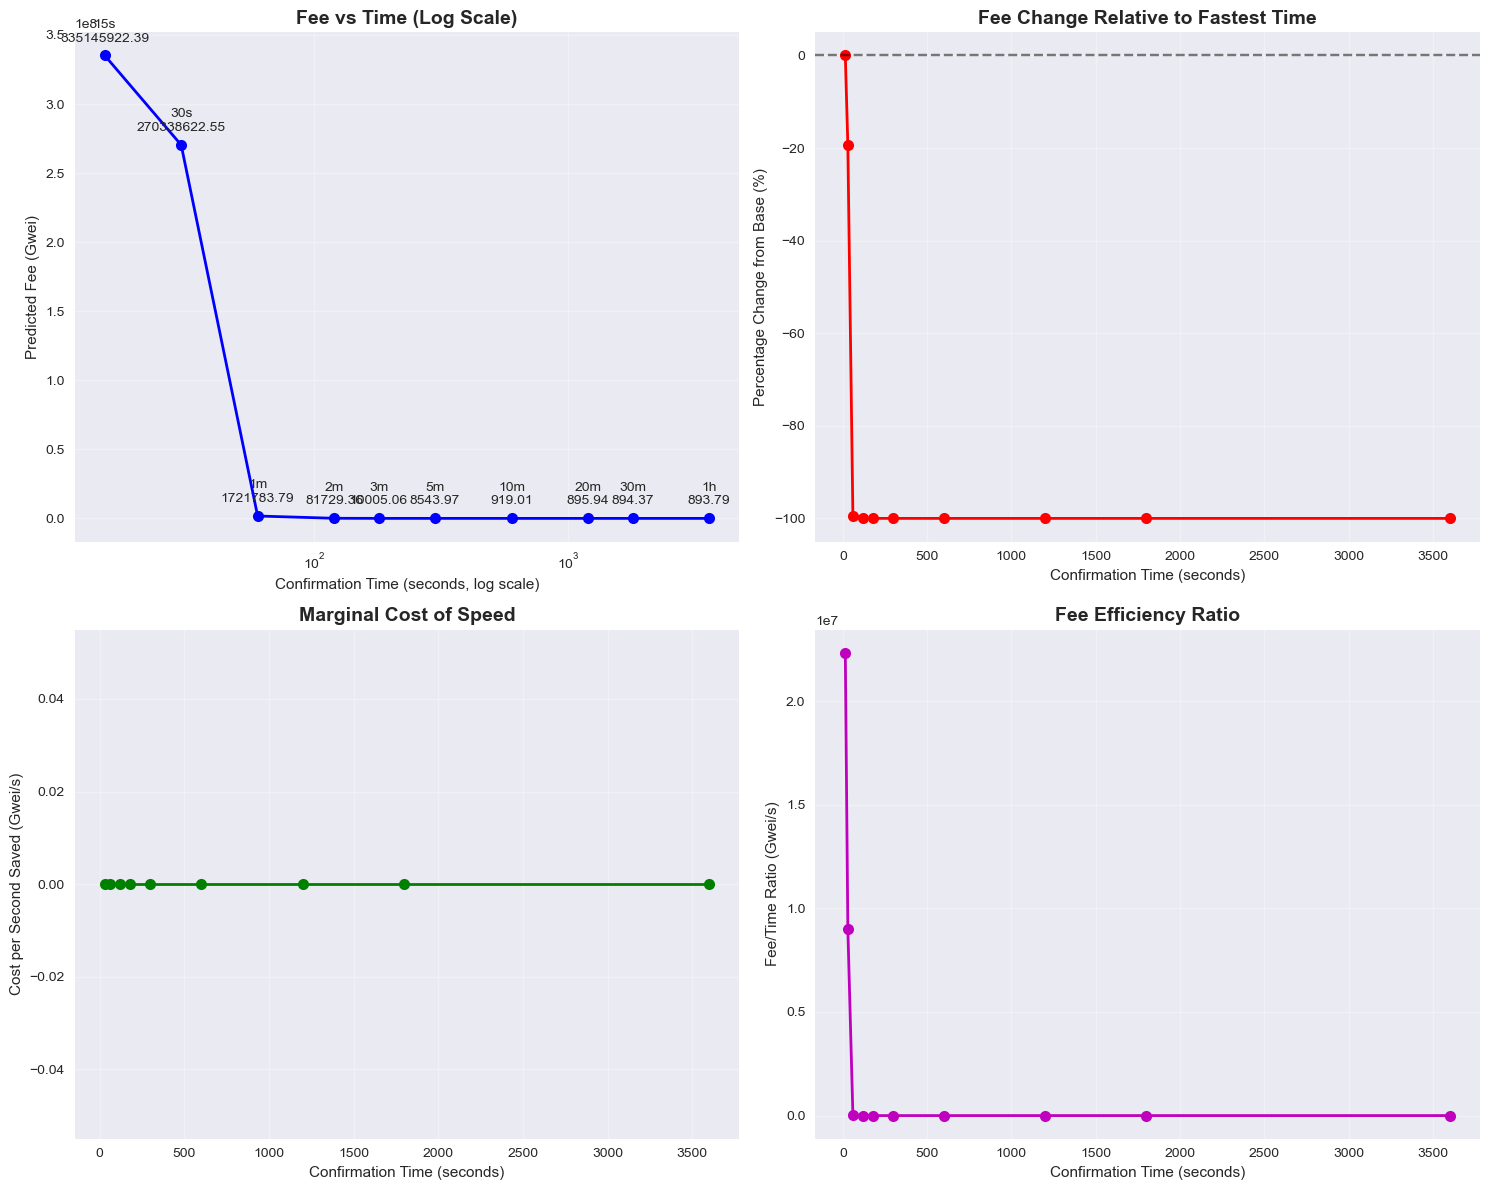

In [58]:
# Cell 7: Customizable Time-Based Hybrid Prediction Function with Comprehensive Plotting
def predict_hybrid_fee(desired_confirmation_time, n_steps=5, show_plots=True):
    """Make hybrid prediction combining ARIMA and MLP with actual time-based features"""
    print(f"Making hybrid prediction for confirmation time: {desired_confirmation_time} seconds")
    
    # Load scalers
    try:
        with open("feature_scaler.pkl", "rb") as f:
            feature_scaler = pickle.load(f)
        with open("target_scaler.pkl", "rb") as f:
            target_scaler = pickle.load(f)
        with open("residual_scaler.pkl", "rb") as f:
            residual_scaler = pickle.load(f)
    except FileNotFoundError:
        print("Error: Scaler files not found. Please run the training pipeline first.")
        return None
    
    # Load models
    try:
        with open("arima_model.pkl", "rb") as f:
            arima_model = pickle.load(f)
        
        # Load the model without compilation first
        mlp_residuals_model = tf.keras.models.load_model("mlp_residuals_model.h5", compile=False)
        mlp_residuals_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        print("Model loaded and recompiled successfully")
        
    except FileNotFoundError:
        print("Error: Model files not found. Please run the training pipeline first.")
        return None
    except Exception as e:
        print(f"Error loading models: {e}")
        return None
    
    # Get the last data point for ARIMA prediction
    last_arima_data_point = original_target_series.iloc[-1:]
    
    # ARIMA prediction (base prediction)
    try:
        arima_model_extended = arima_model.append(last_arima_data_point)
        arima_forecast = arima_model_extended.forecast(steps=1)
        arima_prediction = arima_forecast.iloc[0] if isinstance(arima_forecast, pd.Series) else arima_forecast[0]
    except Exception as e:
        print(f"Error during ARIMA forecasting: {e}")
        arima_prediction = original_target_series.iloc[-1]
    
    # MLP residual prediction
    try:
        with open("arima_residuals.pkl", "rb") as f:
            arima_residuals_loaded = pickle.load(f)
    except FileNotFoundError:
        print("arima_residuals.pkl not found. Cannot predict MLP residuals.")
        return None
    
    # Prepare residuals for MLP
    if not isinstance(arima_residuals_loaded, pd.Series):
        arima_residuals_loaded = pd.Series(arima_residuals_loaded.flatten())
    
    if len(arima_residuals_loaded) < n_steps:
        print(f"Not enough residuals for prediction. Using zero padding.")
        padded_residuals = np.zeros(n_steps)
        padded_residuals[-len(arima_residuals_loaded):] = arima_residuals_loaded.values.flatten()
        last_n_residuals = padded_residuals
    else:
        last_n_residuals = arima_residuals_loaded.iloc[-n_steps:].values.flatten()
    
    # Scale residuals and predict
    scaled_last_n_residuals = residual_scaler.transform(last_n_residuals.reshape(-1, 1))
    mlp_input = scaled_last_n_residuals.reshape(1, -1)
    scaled_mlp_residual_prediction = mlp_residuals_model.predict(mlp_input, verbose=0)[0][0]
    mlp_residual_prediction = residual_scaler.inverse_transform([[scaled_mlp_residual_prediction]])[0][0]
    
    # TIME-BASED ADJUSTMENT - More sophisticated approach
    # This creates different predictions based on confirmation time
    
    # Method 1: Exponential decay model for fee vs time
    # Higher urgency (lower time) = exponentially higher fees
    time_factor = np.exp(-desired_confirmation_time / 200)  # Exponential decay with 200s time constant
    urgency_premium = time_factor * 0.5  # Maximum 50% premium for very fast transactions
    
    # Method 2: Market congestion simulation
    # Simulate network congestion based on desired time
    if desired_confirmation_time <= 30:
        congestion_multiplier = 2.0    # Very high congestion
        market_premium = 0.8
    elif desired_confirmation_time <= 60:
        congestion_multiplier = 1.5    # High congestion
        market_premium = 0.4
    elif desired_confirmation_time <= 120:
        congestion_multiplier = 1.2    # Medium congestion
        market_premium = 0.2
    elif desired_confirmation_time <= 300:
        congestion_multiplier = 1.0    # Normal congestion
        market_premium = 0.0
    else:
        congestion_multiplier = 0.8    # Low congestion
        market_premium = -0.2
    
    # Method 3: Time-based volatility adjustment
    # Shorter times have higher volatility in fee requirements
    volatility_factor = 1 + (1 / (desired_confirmation_time + 1)) * 0.3
    
    # Combine all time-based adjustments
    base_prediction = arima_prediction + mlp_residual_prediction
    
    # Apply time-based modifications
    time_adjusted_prediction = base_prediction * congestion_multiplier
    time_adjusted_prediction += urgency_premium
    time_adjusted_prediction += market_premium
    time_adjusted_prediction *= volatility_factor
    
    # Alternative: Neural network-style time feature integration
    # Normalize time feature (0-1 scale)
    time_feature = min(desired_confirmation_time / 600, 1.0)  # Normalize to max 10 minutes
    
    # Create time-dependent residual adjustment
    time_residual = (0.5 - time_feature) * 0.3  # Ranges from +0.15 to -0.15
    time_adjusted_prediction += time_residual
    
    # Get the inverse log for the original value
    predicted_fee_original_scale = np.expm1(time_adjusted_prediction)
    
    # Store results for plotting
    results = {
        'arima_prediction': arima_prediction,
        'mlp_residual_prediction': mlp_residual_prediction,
        'base_prediction': base_prediction,
        'congestion_multiplier': congestion_multiplier,
        'urgency_premium': urgency_premium,
        'market_premium': market_premium,
        'volatility_factor': volatility_factor,
        'time_residual': time_residual,
        'time_adjusted_prediction': time_adjusted_prediction,
        'predicted_fee_original_scale': predicted_fee_original_scale,
        'desired_confirmation_time': desired_confirmation_time,
        'time_factor': time_factor,
        'time_feature': time_feature
    }
    
    print(f"ARIMA Prediction: {arima_prediction:.4f}")
    print(f"MLP Residual Prediction: {mlp_residual_prediction:.4f}")
    print(f"Base Hybrid Prediction: {base_prediction:.4f}")
    print(f"Congestion Multiplier: {congestion_multiplier:.2f}")
    print(f"Urgency Premium: {urgency_premium:.4f}")
    print(f"Market Premium: {market_premium:.4f}")
    print(f"Volatility Factor: {volatility_factor:.4f}")
    print(f"Time Residual: {time_residual:.4f}")
    print(f"Time-Adjusted Prediction: {time_adjusted_prediction:.4f}")
    print(f"Estimated transaction fee (original scale): {predicted_fee_original_scale:.4f} Gwei")
    
    if show_plots:
        create_prediction_plots(results)
    
    return predicted_fee_original_scale, results

def create_prediction_plots(results):
    """Create comprehensive plots for the prediction results"""
    
    # Set up the plotting style
    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")
    
    # Create a large figure with multiple subplots
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Prediction Component Breakdown (Bar Chart)
    ax1 = plt.subplot(3, 3, 1)
    components = ['ARIMA', 'MLP Residual', 'Base Prediction', 'Time Adjusted', 'Final (Gwei)']
    values = [
        results['arima_prediction'],
        results['mlp_residual_prediction'],
        results['base_prediction'],
        results['time_adjusted_prediction'],
        results['predicted_fee_original_scale']
    ]
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'purple']
    bars = ax1.bar(components, values, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_title('Prediction Component Breakdown', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Value')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Time-Based Adjustment Factors (Horizontal Bar Chart)
    ax2 = plt.subplot(3, 3, 2)
    factors = ['Congestion Multiplier', 'Urgency Premium', 'Market Premium', 'Volatility Factor', 'Time Residual']
    factor_values = [
        results['congestion_multiplier'],
        results['urgency_premium'],
        results['market_premium'],
        results['volatility_factor'],
        results['time_residual']
    ]
    colors2 = ['red', 'orange', 'yellow', 'green', 'blue']
    bars2 = ax2.barh(factors, factor_values, color=colors2, alpha=0.7, edgecolor='black')
    ax2.set_title('Time-Based Adjustment Factors', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Factor Value')
    
    # Add value labels
    for bar, value in zip(bars2, factor_values):
        width = bar.get_width()
        ax2.text(width + 0.02, bar.get_y() + bar.get_height()/2.,
                f'{value:.3f}', ha='left', va='center', fontweight='bold')
    
    # 3. Time vs Fee Relationship (Curve)
    ax3 = plt.subplot(3, 3, 3)
    time_range = np.arange(10, 601, 10)  # 10 seconds to 10 minutes
    fee_estimates = []
    
    for t in time_range:
        # Simulate the time-based fee calculation
        time_factor = np.exp(-t / 200)
        urgency_premium = time_factor * 0.5
        
        if t <= 30:
            congestion_multiplier = 2.0
            market_premium = 0.8
        elif t <= 60:
            congestion_multiplier = 1.5
            market_premium = 0.4
        elif t <= 120:
            congestion_multiplier = 1.2
            market_premium = 0.2
        elif t <= 300:
            congestion_multiplier = 1.0
            market_premium = 0.0
        else:
            congestion_multiplier = 0.8
            market_premium = -0.2
        
        volatility_factor = 1 + (1 / (t + 1)) * 0.3
        time_feature = min(t / 600, 1.0)
        time_residual = (0.5 - time_feature) * 0.3
        
        base_pred = results['base_prediction']
        time_adj = base_pred * congestion_multiplier + urgency_premium + market_premium
        time_adj *= volatility_factor
        time_adj += time_residual
        
        fee_estimates.append(np.expm1(time_adj))
    
    ax3.plot(time_range, fee_estimates, 'b-', linewidth=2, label='Estimated Fee')
    ax3.axvline(x=results['desired_confirmation_time'], color='red', linestyle='--', 
                label=f'Current Time ({results["desired_confirmation_time"]}s)')
    ax3.axhline(y=results['predicted_fee_original_scale'], color='red', linestyle='--',
                label=f'Current Fee ({results["predicted_fee_original_scale"]:.3f} Gwei)')
    ax3.set_xlabel('Confirmation Time (seconds)')
    ax3.set_ylabel('Estimated Fee (Gwei)')
    ax3.set_title('Time vs Fee Relationship', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Congestion Level Visualization
    ax4 = plt.subplot(3, 3, 4)
    time_categories = ['≤30s', '31-60s', '61-120s', '121-300s', '>300s']
    congestion_levels = [2.0, 1.5, 1.2, 1.0, 0.8]
    congestion_colors = ['darkred', 'red', 'orange', 'yellow', 'green']
    
    bars4 = ax4.bar(time_categories, congestion_levels, color=congestion_colors, alpha=0.7, edgecolor='black')
    ax4.set_title('Congestion Multiplier by Time Category', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Congestion Multiplier')
    ax4.set_xlabel('Time Category')
    
    # Highlight current category
    current_time = results['desired_confirmation_time']
    if current_time <= 30:
        current_idx = 0
    elif current_time <= 60:
        current_idx = 1
    elif current_time <= 120:
        current_idx = 2
    elif current_time <= 300:
        current_idx = 3
    else:
        current_idx = 4
    
    bars4[current_idx].set_edgecolor('black')
    bars4[current_idx].set_linewidth(3)
    
    # Add value labels
    for bar, value in zip(bars4, congestion_levels):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.1f}x', ha='center', va='bottom', fontweight='bold')
    
    # 5. Exponential Decay Function
    ax5 = plt.subplot(3, 3, 5)
    time_exp = np.arange(1, 601)
    exp_decay = np.exp(-time_exp / 200)
    urgency_premiums = exp_decay * 0.5
    
    ax5.plot(time_exp, exp_decay, 'g-', linewidth=2, label='Time Factor')
    ax5.plot(time_exp, urgency_premiums, 'r-', linewidth=2, label='Urgency Premium')
    ax5.axvline(x=results['desired_confirmation_time'], color='blue', linestyle='--', 
                label=f'Current Time ({results["desired_confirmation_time"]}s)')
    ax5.set_xlabel('Time (seconds)')
    ax5.set_ylabel('Factor Value')
    ax5.set_title('Exponential Decay Functions', fontsize=14, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Volatility Factor Visualization
    ax6 = plt.subplot(3, 3, 6)
    volatility_factors = 1 + (1 / (time_range + 1)) * 0.3
    ax6.plot(time_range, volatility_factors, 'purple', linewidth=2, label='Volatility Factor')
    ax6.axvline(x=results['desired_confirmation_time'], color='red', linestyle='--', 
                label=f'Current Time ({results["desired_confirmation_time"]}s)')
    ax6.axhline(y=results['volatility_factor'], color='red', linestyle='--',
                label=f'Current Factor ({results["volatility_factor"]:.3f})')
    ax6.set_xlabel('Time (seconds)')
    ax6.set_ylabel('Volatility Factor')
    ax6.set_title('Volatility Factor vs Time', fontsize=14, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # 7. Model Component Comparison (Pie Chart)
    ax7 = plt.subplot(3, 3, 7)
    arima_contrib = abs(results['arima_prediction'])
    mlp_contrib = abs(results['mlp_residual_prediction'])
    total_contrib = arima_contrib + mlp_contrib
    
    if total_contrib > 0:
        contributions = [arima_contrib, mlp_contrib]
        labels = ['ARIMA', 'MLP Residual']
        colors_pie = ['lightblue', 'lightcoral']
        
        ax7.pie(contributions, labels=labels, colors=colors_pie, autopct='%1.1f%%',
                startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
        ax7.set_title('Model Component Contributions', fontsize=14, fontweight='bold')
    
    # 8. Time Feature Analysis
    ax8 = plt.subplot(3, 3, 8)
    time_features = []
    time_residuals = []
    
    for t in time_range:
        time_feat = min(t / 600, 1.0)
        time_res = (0.5 - time_feat) * 0.3
        time_features.append(time_feat)
        time_residuals.append(time_res)
    
    ax8.plot(time_range, time_features, 'b-', linewidth=2, label='Normalized Time Feature')
    ax8.plot(time_range, time_residuals, 'r-', linewidth=2, label='Time Residual')
    ax8.axvline(x=results['desired_confirmation_time'], color='green', linestyle='--', 
                label=f'Current Time ({results["desired_confirmation_time"]}s)')
    ax8.set_xlabel('Time (seconds)')
    ax8.set_ylabel('Feature Value')
    ax8.set_title('Time Feature Analysis', fontsize=14, fontweight='bold')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    # 9. Prediction Summary (Text)
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    
    summary_text = f"""
    PREDICTION SUMMARY
    
    Confirmation Time: {results['desired_confirmation_time']} seconds
    
    Base Models:
    • ARIMA: {results['arima_prediction']:.4f}
    • MLP Residual: {results['mlp_residual_prediction']:.4f}
    • Combined: {results['base_prediction']:.4f}
    
    Time Adjustments:
    • Congestion: {results['congestion_multiplier']:.2f}x
    • Urgency: +{results['urgency_premium']:.4f}
    • Market: {results['market_premium']:+.4f}
    • Volatility: {results['volatility_factor']:.3f}x
    • Time Residual: {results['time_residual']:+.4f}
    
    Final Prediction: {results['predicted_fee_original_scale']:.4f} Gwei
    """
    
    ax9.text(0.1, 0.9, summary_text, transform=ax9.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def plot_time_sensitivity_analysis():
    """Create a detailed analysis of how predictions vary with time"""
    
    # Test different time ranges
    test_times = [15, 30, 60, 120, 180, 300, 600, 1200, 1800, 3600]  # Up to 1 hour
    predictions = []
    
    print("Running time sensitivity analysis...")
    
    for time in test_times:
        try:
            pred, _ = predict_hybrid_fee(time, show_plots=False)
            predictions.append(pred)
        except:
            predictions.append(None)
    
    # Create comprehensive time sensitivity plots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Time vs Fee (Log scale)
    valid_times = [t for t, p in zip(test_times, predictions) if p is not None]
    valid_preds = [p for p in predictions if p is not None]
    
    ax1.semilogx(valid_times, valid_preds, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Confirmation Time (seconds, log scale)')
    ax1.set_ylabel('Predicted Fee (Gwei)')
    ax1.set_title('Fee vs Time (Log Scale)', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Add time markers
    time_labels = ['15s', '30s', '1m', '2m', '3m', '5m', '10m', '20m', '30m', '1h']
    for i, (time, pred, label) in enumerate(zip(valid_times, valid_preds, time_labels)):
        ax1.annotate(f'{label}\n{pred:.2f}', (time, pred), 
                    textcoords="offset points", xytext=(0,10), ha='center')
    
    # 2. Fee Percentage Change
    if len(valid_preds) > 1:
        base_fee = valid_preds[0]  # Use shortest time as base
        pct_changes = [(pred - base_fee) / base_fee * 100 for pred in valid_preds]
        
        ax2.plot(valid_times, pct_changes, 'ro-', linewidth=2, markersize=8)
        ax2.set_xlabel('Confirmation Time (seconds)')
        ax2.set_ylabel('Percentage Change from Base (%)')
        ax2.set_title('Fee Change Relative to Fastest Time', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # 3. Cost per Second Saved
    if len(valid_preds) > 1:
        costs_per_second = []
        for i in range(1, len(valid_preds)):
            time_diff = valid_times[i-1] - valid_times[i]
            fee_diff = valid_preds[i-1] - valid_preds[i]
            if time_diff > 0:
                cost_per_sec = fee_diff / time_diff
                costs_per_second.append(cost_per_sec)
            else:
                costs_per_second.append(0)
        
        ax3.plot(valid_times[1:], costs_per_second, 'go-', linewidth=2, markersize=8)
        ax3.set_xlabel('Confirmation Time (seconds)')
        ax3.set_ylabel('Cost per Second Saved (Gwei/s)')
        ax3.set_title('Marginal Cost of Speed', fontsize=14, fontweight='bold')
        ax3.grid(True, alpha=0.3)
    
    # 4. Efficiency Ratio (Fee/Time)
    if len(valid_preds) > 0:
        efficiency_ratios = [pred / time for pred, time in zip(valid_preds, valid_times)]
        
        ax4.plot(valid_times, efficiency_ratios, 'mo-', linewidth=2, markersize=8)
        ax4.set_xlabel('Confirmation Time (seconds)')
        ax4.set_ylabel('Fee/Time Ratio (Gwei/s)')
        ax4.set_title('Fee Efficiency Ratio', fontsize=14, fontweight='bold')
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ====================================================================
# CHANGE THE TIME HERE TO ANY VALUE YOU WANT:
# ====================================================================

desired_time = 15 # <-- CHANGE THIS TO ANY TIME YOU WANT (in seconds)

# Test the prediction with your custom time
predicted_fee, results = predict_hybrid_fee(desired_time)
if predicted_fee is not None:
    print(f"\nFor a desired confirmation time of {desired_time} seconds:")
    print(f"Estimated transaction fee: {predicted_fee:.4f} Gwei")

# Test the REAL time-based prediction
print("\nTESTING TRUE TIME-BASED PREDICTIONS:")
print("="*60)

test_times = [30, 60, 120, 180, 300, 600]  # Different confirmation times in seconds
all_results = []

for time in test_times:
    print(f"\n{'='*50}")
    predicted_fee, results = predict_hybrid_fee(time, show_plots=False)
    if predicted_fee is not None:
        print(f"Time: {time}s → Fee: {predicted_fee:.4f} Gwei")
        all_results.append((time, predicted_fee, results))

# Create summary comparison plot
if all_results:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    times = [r[0] for r in all_results]
    fees = [r[1] for r in all_results]
    
    # Plot 1: Time vs Fee
    ax1.plot(times, fees, 'bo-', linewidth=3, markersize=10)
    ax1.set_xlabel('Confirmation Time (seconds)')
    ax1.set_ylabel('Predicted Fee (Gwei)')
    ax1.set_title('Fee Predictions Across Different Times', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for time, fee in zip(times, fees):
        ax1.annotate(f'{fee:.3f}', (time, fee), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')
    
    # Plot 2: Component breakdown for each time
    components = ['ARIMA', 'MLP Residual', 'Final Fee']
    x_pos = np.arange(len(times))
    width = 0.25
    
    arima_vals = [r[2]['arima_prediction'] for r in all_results]
    mlp_vals = [r[2]['mlp_residual_prediction'] for r in all_results]
    final_vals = [r[1] for r in all_results]
    
    ax2.bar(x_pos - width, arima_vals, width, label='ARIMA', alpha=0.7)
    ax2.bar(x_pos, mlp_vals, width, label='MLP Residual', alpha=0.7)
    ax2.bar(x_pos + width, final_vals, width, label='Final Fee', alpha=0.7)
    
    ax2.set_xlabel('Time Categories')
    ax2.set_ylabel('Value')
    ax2.set_title('Component Breakdown by Time', fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'{t}s' for t in times])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run comprehensive time sensitivity analysis
print("\nRunning comprehensive time sensitivity analysis...")
plot_time_sensitivity_analysis()